# Truth-free filtered-LCB experiment — result analysis

This notebook analyzes the outputs of the **truth-free filtered-LCB reselection experiment** stored locally under:

`C:\Users\yangy\26 spring\with reference\lcb`

## Main goal

The primary target is **pointwise coverage**, not mean coverage.

So the notebook emphasizes:

- pointwise coverage curve by strategy
- number of undercovered test points
- minimum pointwise coverage
- lower-tail pointwise coverage (e.g. 10th percentile)
- worst covered `x`
- truth-free diagnostics such as:
  - pseudo-transfer gap
  - direction instability
  - width ratio
  - center / scale shift

## Expected layout

The root directory is expected to contain:

- `overall_compare.csv`
- `pointwise_compare.csv`
- `offline_compare.csv` (if offline evaluation exists)
- strategy folders such as:
  - `baseline_replay/`
  - `lcb_direction/`
  - `filtered_lcb_proxy__lam_0.500__tau_0.020/`
  - `filtered_lcb_proxy__lam_1.000__tau_0.020/`
  - ...

Each strategy folder may contain:

- `overall_summary_<strategy>.csv`
- `pointwise_summary_<strategy>.csv`
- per-rep selected outputs like `selected_<strategy>_rep000.csv`

This notebook does **not** perform reselection. It only analyzes saved outputs.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 160

ROOT = Path(r"C:\Users\yangy\26 spring\with reference\lcb")
OUT_DIR = ROOT / "analysis_notebook_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT   =", ROOT)
print("OUT_DIR=", OUT_DIR)


ROOT   = C:\Users\yangy\26 spring\with reference\lcb
OUT_DIR= C:\Users\yangy\26 spring\with reference\lcb\analysis_notebook_outputs


## 1. Discover files

In [2]:
all_items = sorted(ROOT.iterdir())
for p in all_items:
    print(p.name)


.ipynb_checkpoints
analysis_notebook_outputs
baseline_replay
compare_dir_sd_mean.png
compare_g_pseudo_mean.png
compare_offline_pointwise_coverage.png
compare_offline_undercovered_count.png
filtered_lcb_proxy__lam_0.500__tau_0.020
filtered_lcb_proxy__lam_1.000__tau_0.020
filtered_lcb_proxy__lam_2.000__tau_0.020
filtered_lcb_proxy__lam_3.000__tau_0.020
lcb_direction
lcb_result_analysis.ipynb
offline_compare.csv
overall_compare.csv
pointwise_compare.csv
run_metadata.json


In [3]:
overall_compare_path = ROOT / "overall_compare.csv"
pointwise_compare_path = ROOT / "pointwise_compare.csv"
offline_compare_path = ROOT / "offline_compare.csv"

if not overall_compare_path.exists():
    raise FileNotFoundError(f"Missing {overall_compare_path}")
if not pointwise_compare_path.exists():
    raise FileNotFoundError(f"Missing {pointwise_compare_path}")

overall_compare = pd.read_csv(overall_compare_path)
pointwise_compare = pd.read_csv(pointwise_compare_path)
offline_compare = pd.read_csv(offline_compare_path) if offline_compare_path.exists() else None

print("overall_compare shape =", overall_compare.shape)
print("pointwise_compare shape =", pointwise_compare.shape)
print("offline_compare shape =", None if offline_compare is None else offline_compare.shape)


overall_compare shape = (6, 17)
pointwise_compare shape = (300, 14)
offline_compare shape = (6, 11)


## 2. Basic tables

In [4]:
overall_compare


,strategy,num_reps,mean_alpha_star,mean_calib_cov_cf,mean_dep_cov_pseudo,mean_g_pseudo,mean_width_ratio,mean_center_shift,mean_scale_shift,mean_dir_sd,offline_mean_coverage,offline_mean_pointwise_coverage,offline_min_pointwise_coverage,offline_q10_pointwise_coverage,offline_undercovered_points_nominal_095,offline_worst_x,offline_worst_x_coverage
0,baseline_replay,100,0.93140,0.981413,0.97406,-0.007353,0.689658,0.231664,-0.374246,0.027131,0.9834,0.9834,0.92,0.940,7,-2.193878,0.92
1,lcb_direction,100,0.87784,0.986691,0.98032,-0.006371,0.691316,0.222830,-0.371721,0.018703,0.9856,0.9856,0.92,0.949,5,-1.581633,0.92
2,filtered_lcb_proxy__lam_0.500__tau_0.020,100,0.87082,0.985928,0.99954,0.013612,0.695058,0.218394,-0.366644,0.018938,0.9926,0.9926,0.93,0.970,3,-2.193878,0.93
3,filtered_lcb_proxy__lam_1.000__tau_0.020,100,0.89466,0.983442,0.99954,0.016098,0.694855,0.223075,-0.367080,0.021585,0.9922,0.9922,0.92,0.970,3,-1.887755,0.92
4,filtered_lcb_proxy__lam_2.000__tau_0.020,100,0.90676,0.981503,0.99952,0.018017,0.695123,0.226408,-0.366863,0.024151,0.9916,0.9916,0.91,0.970,3,-2.193878,0.91
5,filtered_lcb_proxy__lam_3.000__tau_0.020,100,0.90936,0.980854,0.99908,0.018226,0.695048,0.227844,-0.366990,0.024808,0.9914,0.9914,0.90,0.970,3,-2.193878,0.90


In [5]:
pointwise_compare.head()


,x,alpha_star_mean,alpha_star_sd,calib_cov_cf_mean,dep_cov_pseudo_mean,g_pseudo_mean,width_ratio_mean,center_shift_mean,scale_shift_mean,dir_sd_mean,pseudo_hetero_mean,dep_pseudo_z_mean_abs,strategy,offline_pointwise_coverage
0,-2.500000,0.308,0.152209,0.95377,0.950,-0.00377,0.648813,0.560520,-0.432879,0.069368,0.030475,0.547649,baseline_replay,0.99
1,-2.397959,0.907,0.236667,0.97010,0.992,0.02190,0.640568,0.226396,-0.445982,0.045544,0.006128,0.311722,baseline_replay,1.00
2,-2.295918,0.779,0.235829,0.95854,0.922,-0.03654,0.686488,0.461333,-0.376268,0.050374,0.009405,0.659438,baseline_replay,0.93
3,-2.193878,0.543,0.190828,0.96017,0.941,-0.01917,0.682194,0.367206,-0.382505,0.047032,0.009620,0.582900,baseline_replay,0.92
4,-2.091837,0.959,0.135658,0.97940,0.991,0.01160,0.689976,0.108472,-0.371162,0.032832,0.005064,0.395917,baseline_replay,1.00


In [6]:
if offline_compare is not None:
    offline_compare
else:
    print("No offline_compare.csv found.")


## 3. Strategy list and schema checks

In [7]:
strategies = list(overall_compare["strategy"].unique())
strategies


['baseline_replay',
 'lcb_direction',
 'filtered_lcb_proxy__lam_0.500__tau_0.020',
 'filtered_lcb_proxy__lam_1.000__tau_0.020',
 'filtered_lcb_proxy__lam_2.000__tau_0.020',
 'filtered_lcb_proxy__lam_3.000__tau_0.020']

In [8]:
required_pointwise_cols = [
    "x",
    "strategy",
    "alpha_star_mean",
    "alpha_star_sd",
    "calib_cov_cf_mean",
    "dep_cov_pseudo_mean",
    "g_pseudo_mean",
    "width_ratio_mean",
    "center_shift_mean",
    "scale_shift_mean",
    "dir_sd_mean",
]

missing = [c for c in required_pointwise_cols if c not in pointwise_compare.columns]
if missing:
    raise ValueError(f"Missing required pointwise columns: {missing}")
else:
    print("Pointwise schema looks good.")


Pointwise schema looks good.


## 4. Pointwise coverage is the primary metric

In [9]:
has_offline_pointwise = "offline_pointwise_coverage" in pointwise_compare.columns
print("Has offline pointwise coverage:", has_offline_pointwise)


Has offline pointwise coverage: True


In [10]:
if has_offline_pointwise:
    pointwise_pivot = pointwise_compare.pivot(index="x", columns="strategy", values="offline_pointwise_coverage")
    pointwise_pivot.head()
else:
    print("No offline_pointwise_coverage column found.")


## 5. Main ranking table

In [11]:
ranking_cols = [
    "strategy",
    "offline_undercovered_points_nominal_095",
    "offline_min_pointwise_coverage",
    "offline_q10_pointwise_coverage",
    "offline_mean_pointwise_coverage",
    "mean_alpha_star",
    "mean_g_pseudo",
    "mean_dir_sd",
]

if offline_compare is not None:
    available_cols = [c for c in ranking_cols if c in offline_compare.columns]
    ranking_df = offline_compare[available_cols].copy()
    ranking_df = ranking_df.sort_values(
        by=[
            "offline_undercovered_points_nominal_095",
            "offline_min_pointwise_coverage",
            "offline_q10_pointwise_coverage",
        ],
        ascending=[True, False, False],
    ).reset_index(drop=True)
    ranking_df.to_csv(OUT_DIR / "ranking_table.csv", index=False)
    ranking_df
else:
    print("offline_compare.csv is missing, so no ranking table can be built.")


## 6. Plot offline pointwise coverage curves

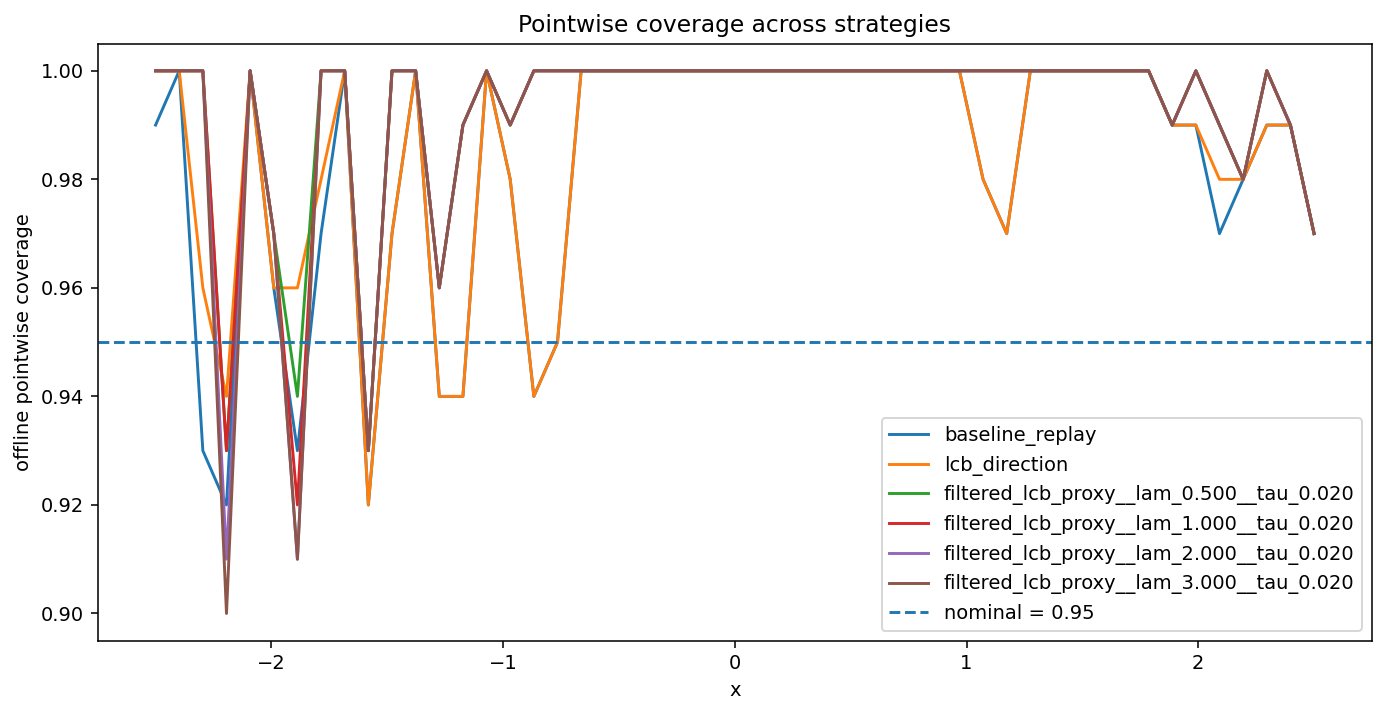

In [12]:
if has_offline_pointwise:
    plt.figure(figsize=(10, 5.2))
    for strategy in strategies:
        df = pointwise_compare.loc[pointwise_compare["strategy"] == strategy].sort_values("x")
        plt.plot(df["x"], df["offline_pointwise_coverage"], label=strategy)
    plt.axhline(0.95, linestyle="--", label="nominal = 0.95")
    plt.xlabel("x")
    plt.ylabel("offline pointwise coverage")
    plt.title("Pointwise coverage across strategies")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "01_pointwise_coverage_curves.png", bbox_inches="tight")
    plt.show()
else:
    print("No offline pointwise coverage available.")


## 7. Undercovered point counts and worst-point summaries

In [13]:
if has_offline_pointwise:
    rows = []
    for strategy in strategies:
        df = pointwise_compare.loc[pointwise_compare["strategy"] == strategy].sort_values("x").reset_index(drop=True)
        cov = df["offline_pointwise_coverage"].to_numpy(dtype=float)
        x = df["x"].to_numpy(dtype=float)

        under_mask = cov < 0.95
        under_count = int(under_mask.sum())
        min_idx = int(np.argmin(cov))

        rows.append({
            "strategy": strategy,
            "undercovered_points": under_count,
            "min_pointwise_coverage": float(cov[min_idx]),
            "worst_x": float(x[min_idx]),
            "q10_pointwise_coverage": float(np.quantile(cov, 0.10)),
            "mean_pointwise_coverage": float(np.mean(cov)),
        })

    under_summary = pd.DataFrame(rows).sort_values(
        ["undercovered_points", "min_pointwise_coverage"],
        ascending=[True, False]
    ).reset_index(drop=True)

    under_summary.to_csv(OUT_DIR / "02_undercovered_summary.csv", index=False)
    under_summary
else:
    print("No offline pointwise coverage available.")


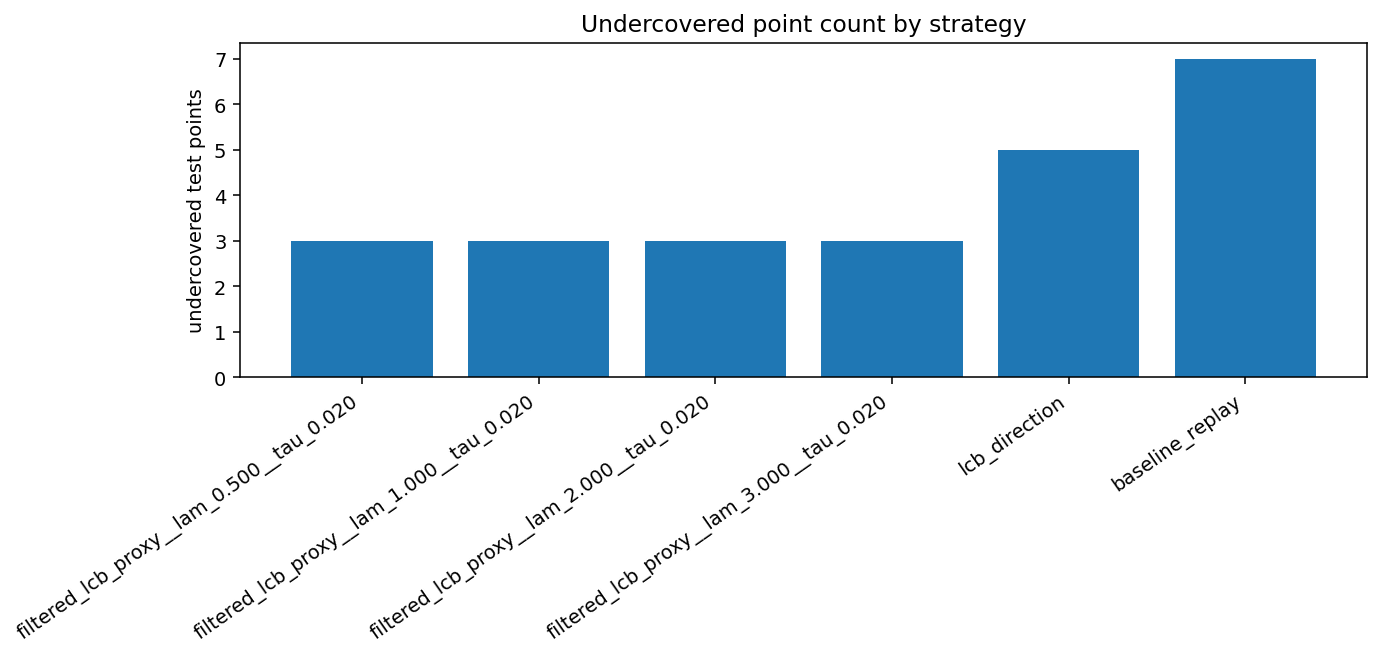

In [14]:
if has_offline_pointwise:
    plt.figure(figsize=(10, 4.8))
    plt.bar(under_summary["strategy"], under_summary["undercovered_points"])
    plt.ylabel("undercovered test points")
    plt.title("Undercovered point count by strategy")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_undercovered_count_bar.png", bbox_inches="tight")
    plt.show()


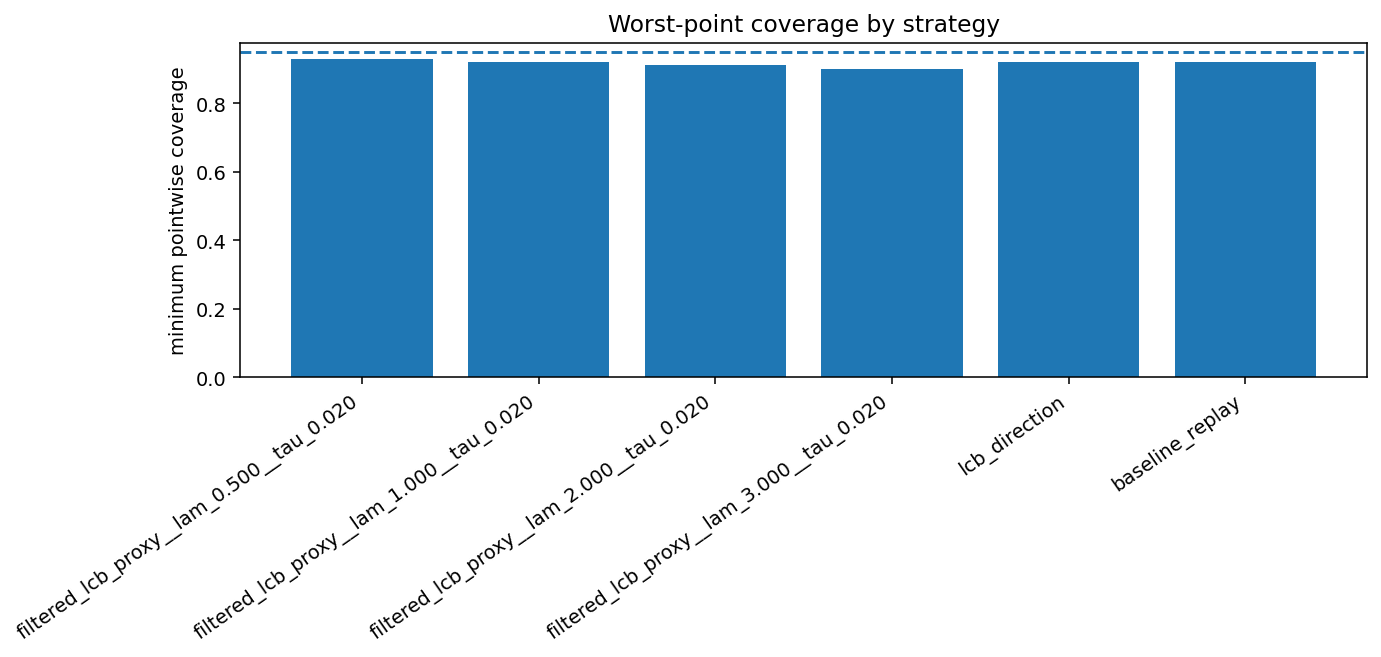

In [15]:
if has_offline_pointwise:
    plt.figure(figsize=(10, 4.8))
    plt.bar(under_summary["strategy"], under_summary["min_pointwise_coverage"])
    plt.axhline(0.95, linestyle="--")
    plt.ylabel("minimum pointwise coverage")
    plt.title("Worst-point coverage by strategy")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "04_min_pointwise_coverage_bar.png", bbox_inches="tight")
    plt.show()


## 8. Truth-free diagnostics: pseudo-transfer gap

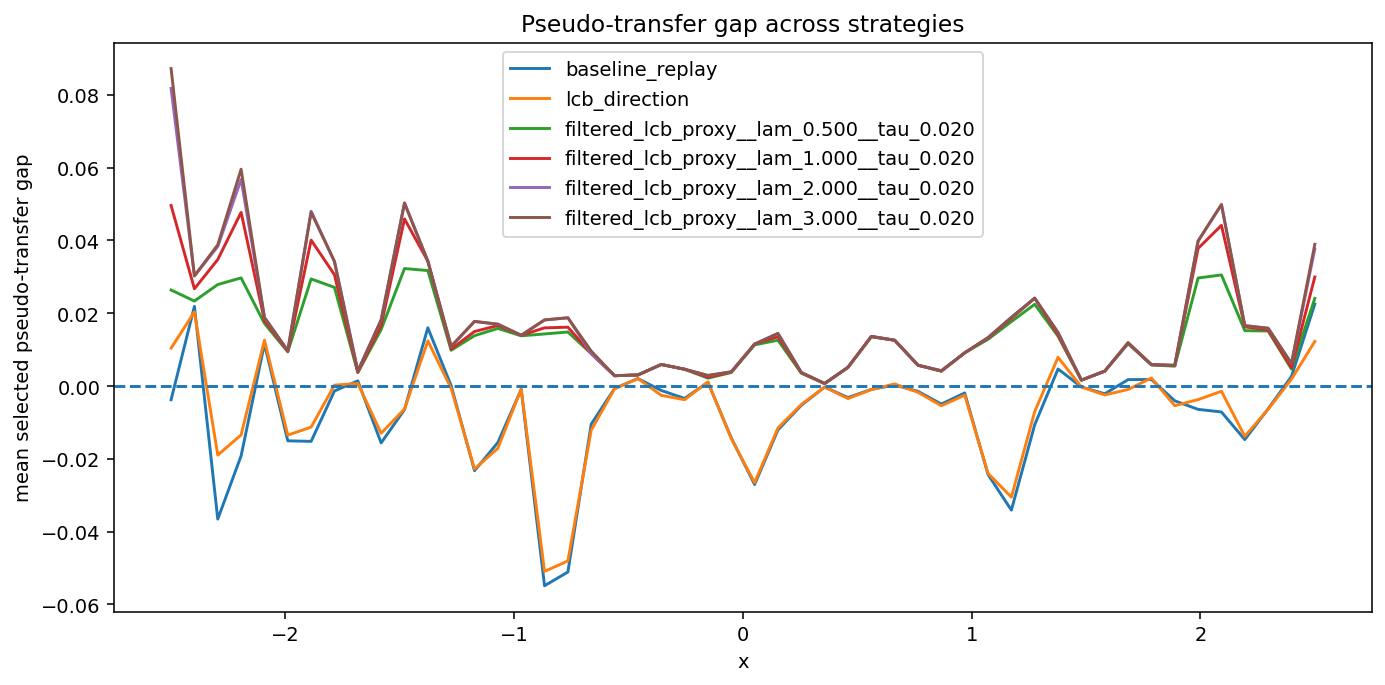

In [16]:
plt.figure(figsize=(10, 5))
for strategy in strategies:
    df = pointwise_compare.loc[pointwise_compare["strategy"] == strategy].sort_values("x")
    plt.plot(df["x"], df["g_pseudo_mean"], label=strategy)
plt.axhline(0.0, linestyle="--")
plt.xlabel("x")
plt.ylabel("mean selected pseudo-transfer gap")
plt.title("Pseudo-transfer gap across strategies")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "05_pseudo_transfer_gap_curves.png", bbox_inches="tight")
plt.show()


In [17]:
pseudo_gap_summary = (
    pointwise_compare.groupby("strategy", as_index=False)
    .agg(
        mean_g_pseudo=("g_pseudo_mean", "mean"),
        min_g_pseudo=("g_pseudo_mean", "min"),
        q10_g_pseudo=("g_pseudo_mean", lambda s: float(np.quantile(s, 0.10))),
    )
    .sort_values("mean_g_pseudo", ascending=False)
    .reset_index(drop=True)
)
pseudo_gap_summary.to_csv(OUT_DIR / "06_pseudo_gap_summary.csv", index=False)
pseudo_gap_summary


,strategy,mean_g_pseudo,min_g_pseudo,q10_g_pseudo
0,filtered_lcb_proxy__lam_3.000__tau_0.020,0.018226,0.00070,0.003671
1,filtered_lcb_proxy__lam_2.000__tau_0.020,0.018017,0.00070,0.003671
2,filtered_lcb_proxy__lam_1.000__tau_0.020,0.016098,0.00070,0.003572
3,filtered_lcb_proxy__lam_0.500__tau_0.020,0.013612,0.00070,0.003500
4,lcb_direction,-0.006371,-0.05091,-0.022882
5,baseline_replay,-0.007353,-0.05485,-0.024565


## 9. Truth-free diagnostics: direction instability

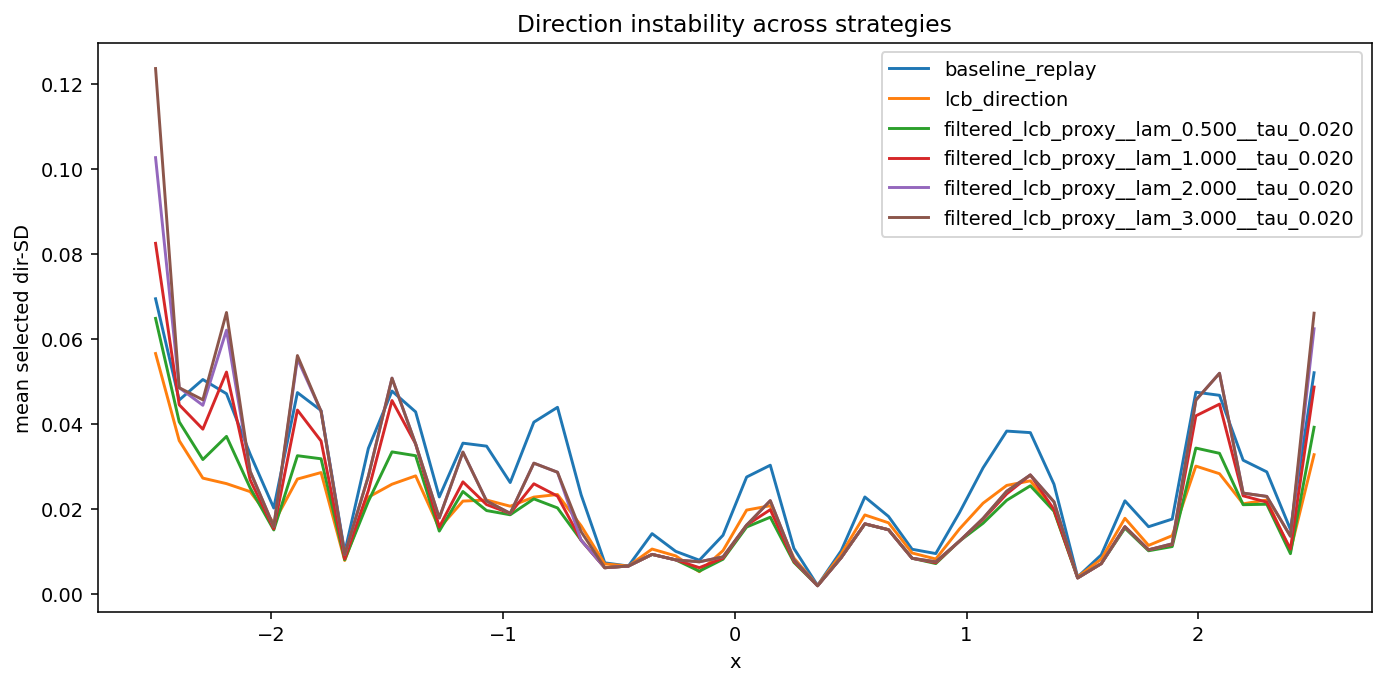

In [18]:
plt.figure(figsize=(10, 5))
for strategy in strategies:
    df = pointwise_compare.loc[pointwise_compare["strategy"] == strategy].sort_values("x")
    plt.plot(df["x"], df["dir_sd_mean"], label=strategy)
plt.xlabel("x")
plt.ylabel("mean selected dir-SD")
plt.title("Direction instability across strategies")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "07_direction_instability_curves.png", bbox_inches="tight")
plt.show()


In [19]:
dir_sd_summary = (
    pointwise_compare.groupby("strategy", as_index=False)
    .agg(
        mean_dir_sd=("dir_sd_mean", "mean"),
        max_dir_sd=("dir_sd_mean", "max"),
        q90_dir_sd=("dir_sd_mean", lambda s: float(np.quantile(s, 0.90))),
    )
    .sort_values("mean_dir_sd", ascending=True)
    .reset_index(drop=True)
)
dir_sd_summary.to_csv(OUT_DIR / "08_dir_sd_summary.csv", index=False)
dir_sd_summary


,strategy,mean_dir_sd,max_dir_sd,q90_dir_sd
0,lcb_direction,0.018703,0.056487,0.028237
1,filtered_lcb_proxy__lam_0.500__tau_0.020,0.018938,0.064753,0.033434
2,filtered_lcb_proxy__lam_1.000__tau_0.020,0.021585,0.082413,0.044443
3,filtered_lcb_proxy__lam_2.000__tau_0.020,0.024151,0.102571,0.050809
4,filtered_lcb_proxy__lam_3.000__tau_0.020,0.024808,0.123536,0.050809
5,baseline_replay,0.027131,0.069368,0.047308


## 10. Other truth-free diagnostics

In [20]:
other_diag_summary = (
    pointwise_compare.groupby("strategy", as_index=False)
    .agg(
        mean_alpha_star=("alpha_star_mean", "mean"),
        mean_width_ratio=("width_ratio_mean", "mean"),
        mean_center_shift=("center_shift_mean", "mean"),
        mean_scale_shift=("scale_shift_mean", "mean"),
        mean_pseudo_hetero=("pseudo_hetero_mean", "mean"),
        mean_dep_pseudo_z=("dep_pseudo_z_mean_abs", "mean"),
    )
)
other_diag_summary.to_csv(OUT_DIR / "09_other_diag_summary.csv", index=False)
other_diag_summary


,strategy,mean_alpha_star,mean_width_ratio,mean_center_shift,mean_scale_shift,mean_pseudo_hetero,mean_dep_pseudo_z
0,baseline_replay,0.93140,0.689658,0.231664,-0.374246,0.00672,0.489701
1,filtered_lcb_proxy__lam_0.500__tau_0.020,0.87082,0.695058,0.218394,-0.366644,0.00672,0.456833
2,filtered_lcb_proxy__lam_1.000__tau_0.020,0.89466,0.694855,0.223075,-0.367080,0.00672,0.464043
3,filtered_lcb_proxy__lam_2.000__tau_0.020,0.90676,0.695123,0.226408,-0.366863,0.00672,0.469524
4,filtered_lcb_proxy__lam_3.000__tau_0.020,0.90936,0.695048,0.227844,-0.366990,0.00672,0.471210
5,lcb_direction,0.87784,0.691316,0.222830,-0.371721,0.00672,0.470617


## 11. Pairwise improvement relative to baseline

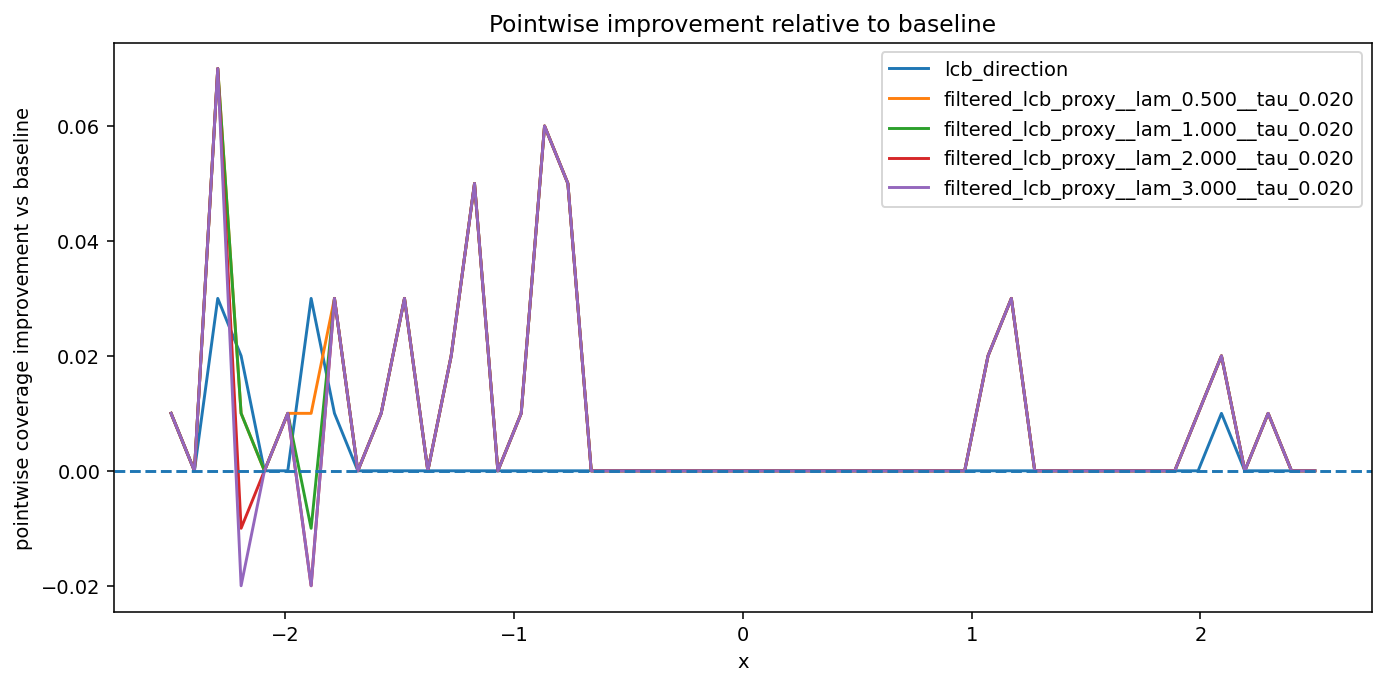

In [21]:
if has_offline_pointwise and "baseline_replay" in strategies:
    base = pointwise_compare.loc[pointwise_compare["strategy"] == "baseline_replay", ["x", "offline_pointwise_coverage"]].copy()
    base = base.rename(columns={"offline_pointwise_coverage": "baseline_offline_pointwise_coverage"})

    pairwise_rows = []
    for strategy in strategies:
        df = pointwise_compare.loc[pointwise_compare["strategy"] == strategy, ["x", "offline_pointwise_coverage"]].copy()
        merged = df.merge(base, on="x", how="left")
        merged["improvement_vs_baseline"] = (
            merged["offline_pointwise_coverage"] - merged["baseline_offline_pointwise_coverage"]
        )
        pairwise_rows.append(
            pd.DataFrame({
                "x": merged["x"],
                "strategy": strategy,
                "improvement_vs_baseline": merged["improvement_vs_baseline"],
            })
        )

    pairwise_improve = pd.concat(pairwise_rows, axis=0, ignore_index=True)
    pairwise_improve.to_csv(OUT_DIR / "10_pairwise_improvement_vs_baseline.csv", index=False)

    plt.figure(figsize=(10, 5))
    for strategy in strategies:
        if strategy == "baseline_replay":
            continue
        df = pairwise_improve.loc[pairwise_improve["strategy"] == strategy].sort_values("x")
        plt.plot(df["x"], df["improvement_vs_baseline"], label=strategy)
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("x")
    plt.ylabel("pointwise coverage improvement vs baseline")
    plt.title("Pointwise improvement relative to baseline")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "11_pairwise_improvement_vs_baseline.png", bbox_inches="tight")
    plt.show()
else:
    print("No offline pointwise coverage or no baseline_replay strategy found.")


## 12. Strategy folders: inspect per-rep outputs if needed

In [22]:
strategy_dirs = [p for p in ROOT.iterdir() if p.is_dir()]
strategy_dirs


[WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/.ipynb_checkpoints'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/analysis_notebook_outputs'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/baseline_replay'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/filtered_lcb_proxy__lam_0.500__tau_0.020'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/filtered_lcb_proxy__lam_1.000__tau_0.020'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/filtered_lcb_proxy__lam_2.000__tau_0.020'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/filtered_lcb_proxy__lam_3.000__tau_0.020'),
 WindowsPath('C:/Users/yangy/26 spring/with reference/lcb/lcb_direction')]

In [23]:
# Example: inspect one strategy's first few per-rep files
for d in strategy_dirs:
    rep_files = sorted(d.glob("selected_*_rep*.csv"))
    print(d.name, "->", len(rep_files), "per-rep files")
    if rep_files:
        print("   first:", rep_files[0].name)


.ipynb_checkpoints -> 0 per-rep files
analysis_notebook_outputs -> 0 per-rep files
baseline_replay -> 100 per-rep files
   first: selected_baseline_replay_rep000.csv
filtered_lcb_proxy__lam_0.500__tau_0.020 -> 100 per-rep files
   first: selected_filtered_lcb_proxy__lam_0.500__tau_0.020_rep000.csv
filtered_lcb_proxy__lam_1.000__tau_0.020 -> 100 per-rep files
   first: selected_filtered_lcb_proxy__lam_1.000__tau_0.020_rep000.csv
filtered_lcb_proxy__lam_2.000__tau_0.020 -> 100 per-rep files
   first: selected_filtered_lcb_proxy__lam_2.000__tau_0.020_rep000.csv
filtered_lcb_proxy__lam_3.000__tau_0.020 -> 100 per-rep files
   first: selected_filtered_lcb_proxy__lam_3.000__tau_0.020_rep000.csv
lcb_direction -> 100 per-rep files
   first: selected_lcb_direction_rep000.csv


## 13. Optional: inspect one strategy in detail

In [24]:
DETAIL_STRATEGY = strategies[0]
DETAIL_REP_FILE = None

detail_dir = ROOT / DETAIL_STRATEGY
rep_files = sorted(detail_dir.glob("selected_*_rep*.csv"))
if rep_files:
    DETAIL_REP_FILE = rep_files[0]

print("DETAIL_STRATEGY =", DETAIL_STRATEGY)
print("DETAIL_REP_FILE =", DETAIL_REP_FILE)


DETAIL_STRATEGY = baseline_replay
DETAIL_REP_FILE = C:\Users\yangy\26 spring\with reference\lcb\baseline_replay\selected_baseline_replay_rep000.csv


In [25]:
if DETAIL_REP_FILE is not None:
    detail_df = pd.read_csv(DETAIL_REP_FILE)
    detail_df.head()
else:
    print("No per-rep file found for the selected strategy.")


## 14. Final recommendation table

In [26]:
if offline_compare is not None:
    rec = ranking_df.copy()
    rec["comment"] = ""

    for i in range(len(rec)):
        row = rec.iloc[i]
        notes = []
        if "offline_undercovered_points_nominal_095" in rec.columns and row["offline_undercovered_points_nominal_095"] == rec["offline_undercovered_points_nominal_095"].min():
            notes.append("fewest undercovered points")
        if "offline_min_pointwise_coverage" in rec.columns and row["offline_min_pointwise_coverage"] == rec["offline_min_pointwise_coverage"].max():
            notes.append("best worst-point coverage")
        if "mean_dir_sd" in rec.columns and row["mean_dir_sd"] == rec["mean_dir_sd"].min():
            notes.append("lowest direction instability")
        rec.at[i, "comment"] = "; ".join(notes)

    rec.to_csv(OUT_DIR / "12_recommendation_table.csv", index=False)
    rec
else:
    print("No offline comparison available.")


## 15. Quick text summary

In [27]:
print("Saved analysis outputs to:", OUT_DIR)
print()

if offline_compare is not None:
    best = ranking_df.iloc[0]
    print("Top strategy by pointwise-focused ranking:")
    print(" strategy =", best["strategy"])
    if "offline_undercovered_points_nominal_095" in ranking_df.columns:
        print(" undercovered points =", int(best["offline_undercovered_points_nominal_095"]))
    if "offline_min_pointwise_coverage" in ranking_df.columns:
        print(" min pointwise coverage =", float(best["offline_min_pointwise_coverage"]))
    if "offline_q10_pointwise_coverage" in ranking_df.columns:
        print(" q10 pointwise coverage =", float(best["offline_q10_pointwise_coverage"]))
    print()

print("Generated files:")
for p in sorted(OUT_DIR.iterdir()):
    print(" ", p.name)


Saved analysis outputs to: C:\Users\yangy\26 spring\with reference\lcb\analysis_notebook_outputs

Top strategy by pointwise-focused ranking:
 strategy = filtered_lcb_proxy__lam_0.500__tau_0.020
 undercovered points = 3
 min pointwise coverage = 0.93
 q10 pointwise coverage = 0.97

Generated files:
  01_pointwise_coverage_curves.png
  02_undercovered_summary.csv
  03_undercovered_count_bar.png
  04_min_pointwise_coverage_bar.png
  05_pseudo_transfer_gap_curves.png
  06_pseudo_gap_summary.csv
  07_direction_instability_curves.png
  08_dir_sd_summary.csv
  09_other_diag_summary.csv
  10_pairwise_improvement_vs_baseline.csv
  11_pairwise_improvement_vs_baseline.png
  12_recommendation_table.csv
  ranking_table.csv
